In [44]:
import os
import random
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from Fastkan import FastKAN

In [45]:
number_of_primitives = 3
visible_range = True#Use False to select entire spectrum
include_shadows = True
no_of_epochs = 30
#Visible range of pavia dataset has 66 bands and full spectrum has 103 bands
no_of_bands = 66 if visible_range else 103
output_classes = 9 if include_shadows else 8

# Loading Pavia Univeristy Dataset

In [46]:
hsi = scipy.io.loadmat("PaviaU.mat")
image = hsi["paviaU"]

gt = scipy.io.loadmat("PaviaU_gt.mat")
index = gt["paviaU_gt"]
image  =image[:, :, :no_of_bands]

print(image.shape)
print(index.shape)

(610, 340, 66)
(610, 340)


In [47]:
#Normalizing the image
max_val = np.max(image)
normalized_image = np.divide(image, max_val)

In [48]:
image_for_training = normalized_image[:,:,:no_of_bands]
print(image_for_training.shape)

(610, 340, 66)


#   Dataset for Training 

In [49]:
x = []
for i in range(len(image_for_training)):
    for j in range(len(image_for_training[0])):
        if (index[i][j] == 0) or (index[i][j] == 9 and (not include_shadows)): #Ignoring all unclassified pixels
            continue
        x.append(image_for_training[i][j])

x = np.asarray(x,dtype=np.float32)
print(x.shape)

(42776, 66)


In [50]:
y = []

for i in range(len(image)):
    for j in range(len(image[0])):
        if index[i][j] == 0 or \
           (index[i][j] == 9 and (not include_shadows)):
            continue

        y.append(index[i][j]-1)

y = np.asarray(y , dtype=np.int64)
y.shape

(42776,)

# Model Defination

In [51]:
class ColorFastKAN(nn.Module):

    def __init__(
        self,
        no_of_bands,
        number_of_primitives,
        output_classes,
    ):
        super().__init__()
        self.primitives = nn.ModuleList([
            FastKAN(
                layers_hidden=[no_of_bands, 1]
            )
            for _ in range(number_of_primitives)
        ])
        self.classifier_kan = FastKAN([
                number_of_primitives,
                output_classes],
        )

    def forward(self, x):
        primitive_outputs = []

        for primitive in self.primitives:
            primitive_output = primitive(x)
            primitive_outputs.append(primitive_output)
        merged = torch.cat(
            primitive_outputs,
            dim=1
        )
        kan_logits = self.classifier_kan(merged)
        return kan_logits
model = ColorFastKAN(
no_of_bands=no_of_bands,
number_of_primitives=number_of_primitives,
output_classes=output_classes)

In [52]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters()
)

In [53]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = model.to(device)

Using device: cpu


In [54]:
print(model)

ColorFastKAN(
  (primitives): ModuleList(
    (0-2): 3 x FastKAN(
      (layers): ModuleList(
        (0): Fast_KANLinear(
          (layernorm): LayerNorm((66,), eps=1e-05, elementwise_affine=True, bias=True)
          (rbf): RadialBasisFunction()
          (spline_linear): SplineLinear(in_features=132, out_features=1, bias=False)
          (base_linear): Linear(in_features=66, out_features=1, bias=True)
        )
      )
    )
  )
  (classifier_kan): FastKAN(
    (layers): ModuleList(
      (0): Fast_KANLinear(
        (layernorm): LayerNorm((3,), eps=1e-05, elementwise_affine=True, bias=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=6, out_features=9, bias=False)
        (base_linear): Linear(in_features=3, out_features=9, bias=True)
      )
    )
  )
)


In [55]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                                  Param #
ColorFastKAN                                            --
├─ModuleList: 1-1                                       --
│    └─FastKAN: 2-1                                     --
│    │    └─ModuleList: 3-1                             331
│    └─FastKAN: 2-2                                     --
│    │    └─ModuleList: 3-2                             331
│    └─FastKAN: 2-3                                     --
│    │    └─ModuleList: 3-3                             331
├─FastKAN: 1-2                                          --
│    └─ModuleList: 2-4                                  --
│    │    └─Fast_KANLinear: 3-4                         96
Total params: 1,089
Trainable params: 1,089
Non-trainable params: 0

In [56]:
from torch.utils.data import TensorDataset, DataLoader

# Convert NumPy arrays to PyTorch tensors
x_tensor = torch.tensor(
    x,
    dtype=torch.float32
)

y_tensor = torch.tensor(
    y,
    dtype=torch.long
)

# Create dataset
dataset = TensorDataset(
    x_tensor,
    y_tensor
)

# Keras model.fit() uses batch_size=32 by default
train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

loss_history = []
accuracy_history = []

for epoch in range(no_of_epochs):

    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        # Forward pass
        output = model(batch_x)

        # Loss calculation
        loss = criterion(
            output,
            batch_y
        )

        # Backpropagation
        loss.backward()

        # Update parameters after each batch
        optimizer.step()

        # Accumulate epoch loss
        total_loss += (
            loss.item() * batch_x.size(0)
        )

        # Predicted classes
        predictions = torch.argmax(
            output,
            dim=1
        )

        total_correct += (
            predictions == batch_y
        ).sum().item()

        total_samples += batch_y.size(0)

    epoch_loss = total_loss / total_samples
    epoch_accuracy = total_correct / total_samples

    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_accuracy)

    print(
        f"Epoch {epoch + 1}/{no_of_epochs} - "
        f"loss: {epoch_loss:.4f} - "
        f"accuracy: {epoch_accuracy:.4f}"
    )

Epoch 1/30 - loss: 1.3124 - accuracy: 0.5598
Epoch 2/30 - loss: 0.8090 - accuracy: 0.7298
Epoch 3/30 - loss: 0.7051 - accuracy: 0.7464
Epoch 4/30 - loss: 0.6510 - accuracy: 0.7659
Epoch 5/30 - loss: 0.6201 - accuracy: 0.7810
Epoch 6/30 - loss: 0.5988 - accuracy: 0.7903
Epoch 7/30 - loss: 0.5830 - accuracy: 0.7946
Epoch 8/30 - loss: 0.5715 - accuracy: 0.8006
Epoch 9/30 - loss: 0.5601 - accuracy: 0.8034
Epoch 10/30 - loss: 0.5501 - accuracy: 0.8072
Epoch 11/30 - loss: 0.5422 - accuracy: 0.8084
Epoch 12/30 - loss: 0.5359 - accuracy: 0.8101
Epoch 13/30 - loss: 0.5348 - accuracy: 0.8101
Epoch 14/30 - loss: 0.5233 - accuracy: 0.8127
Epoch 15/30 - loss: 0.5200 - accuracy: 0.8136
Epoch 16/30 - loss: 0.5151 - accuracy: 0.8138
Epoch 17/30 - loss: 0.5134 - accuracy: 0.8145
Epoch 18/30 - loss: 0.5052 - accuracy: 0.8171
Epoch 19/30 - loss: 0.5022 - accuracy: 0.8176
Epoch 20/30 - loss: 0.4977 - accuracy: 0.8181
Epoch 21/30 - loss: 0.4930 - accuracy: 0.8189
Epoch 22/30 - loss: 0.4906 - accuracy: 0.82

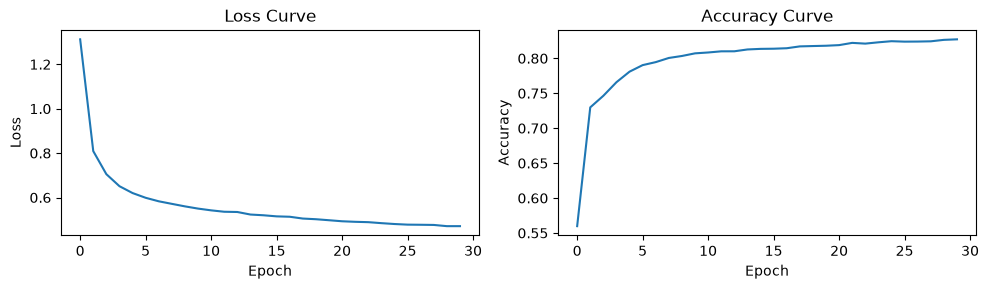

In [57]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(accuracy_history)
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# Plot each learned Filters

In [58]:
wavelength = np.linspace(430, 860, 66) #430 - 860 is range of paviaU dataset and 103 is number of bands
wavelength_int = wavelength.astype(int)
print(wavelength_int)

[430 436 443 449 456 463 469 476 482 489 496 502 509 516 522 529 535 542
 549 555 562 568 575 582 588 595 602 608 615 621 628 635 641 648 654 661
 668 674 681 688 694 701 707 714 721 727 734 740 747 754 760 767 774 780
 787 793 800 807 813 820 826 833 840 846 853 860]


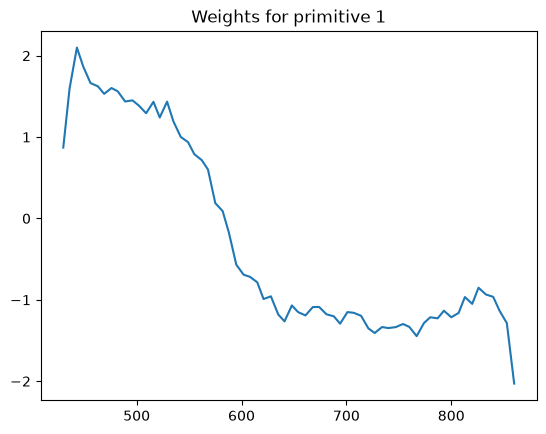

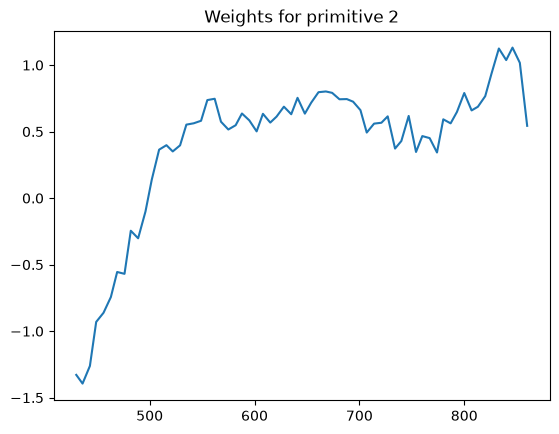

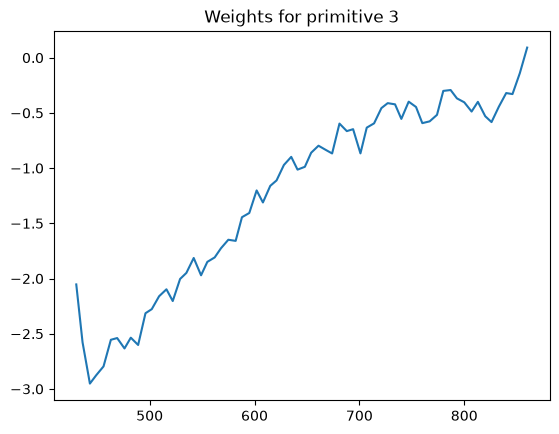

In [59]:
primitive_curves = []

for primitive_no in range(number_of_primitives):

    p = (
        model.primitives[primitive_no]
        .layers[0]
        .base_linear.weight
        .detach()
        .cpu()
        .numpy()[0]
    )

    primitive_curves.append(p)

    plt.plot(
        wavelength_int[:no_of_bands],
        p
    )

    plt.title(
        f"Weights for primitive {primitive_no + 1}"
    )

    plt.show()

In [60]:
for i, primitive in enumerate(model.primitives):

    w = (
        primitive.layers[0]
        .base_linear.weight
        .detach()
        .cpu()
        .numpy()
    )

    print(i + 1,f"primitive_{i + 1}", w[0, 0])

1 primitive_1 0.8704351
2 primitive_2 -1.3284956
3 primitive_3 -2.0532844


In [61]:
for i, (name, parameter) in enumerate(model.named_parameters()):
    if parameter.requires_grad:
        print(i, name, parameter.shape)

0 primitives.0.layers.0.layernorm.weight torch.Size([66])
1 primitives.0.layers.0.layernorm.bias torch.Size([66])
2 primitives.0.layers.0.spline_linear.weight torch.Size([1, 132])
3 primitives.0.layers.0.base_linear.weight torch.Size([1, 66])
4 primitives.0.layers.0.base_linear.bias torch.Size([1])
5 primitives.1.layers.0.layernorm.weight torch.Size([66])
6 primitives.1.layers.0.layernorm.bias torch.Size([66])
7 primitives.1.layers.0.spline_linear.weight torch.Size([1, 132])
8 primitives.1.layers.0.base_linear.weight torch.Size([1, 66])
9 primitives.1.layers.0.base_linear.bias torch.Size([1])
10 primitives.2.layers.0.layernorm.weight torch.Size([66])
11 primitives.2.layers.0.layernorm.bias torch.Size([66])
12 primitives.2.layers.0.spline_linear.weight torch.Size([1, 132])
13 primitives.2.layers.0.base_linear.weight torch.Size([1, 66])
14 primitives.2.layers.0.base_linear.bias torch.Size([1])
15 classifier_kan.layers.0.layernorm.weight torch.Size([3])
16 classifier_kan.layers.0.layernor

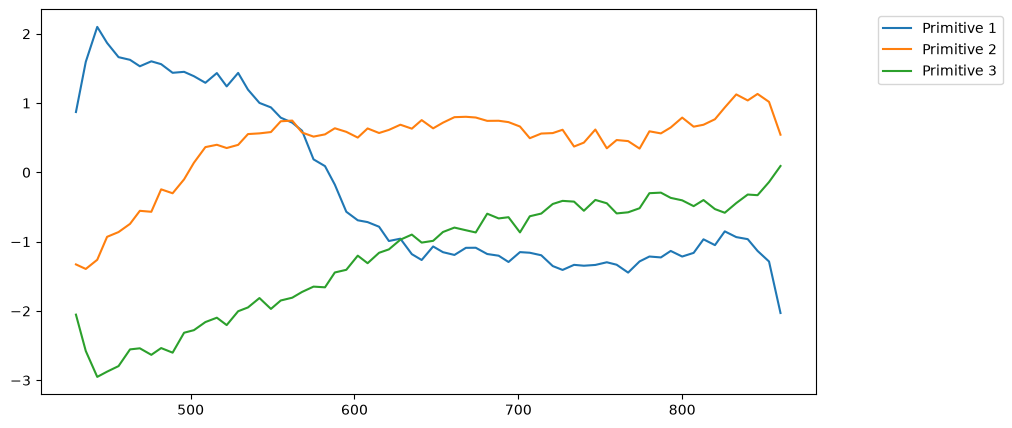

In [62]:
plt.figure(figsize=(10, 5))

for primitive_no in range(number_of_primitives):

    plt.plot(
        wavelength_int[:no_of_bands],
        primitive_curves[primitive_no],
        label=f"Primitive {primitive_no + 1}"
    )
plt.legend(bbox_to_anchor=(1.25, 1))
plt.show()


In [63]:
model_name = (
    f'{no_of_bands}bands_'f'{number_of_primitives}primitives_' f'{"with_shadow" if include_shadows else "without_shadow"}_' f'fastkan_random_init')

In [64]:
print(model_name)

66bands_3primitives_with_shadow_fastkan_random_init


In [65]:
torch.save(model, f"{model_name}.h5")


#Generate Image

In [66]:
def predict_image():

    x_pred = []

    for i in range(len(image_for_training)):
        for j in range(len(image_for_training[0])):
            x_pred.append(image_for_training[i][j])

    x_pred = np.asarray(x_pred)

    print("Prediction Input Shape:", x_pred.shape)
    print("Predicting...")

    x_pred = torch.tensor(
        x_pred,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():

        primitive_outputs = []

        for primitive in model.primitives:
            primitive_outputs.append(
                primitive(x_pred)
            )

        prediction = torch.cat(
            primitive_outputs,
            dim=1
        )

    prediction = prediction.cpu().numpy()

    predicted_image_array = []

    for i in prediction:
        predicted_image_array.append(i)

    predicted_image = []

    pixel = 0

    while pixel < len(predicted_image_array):

        temp = []

        for _ in range(len(image[0])):

            temp.append(
                predicted_image_array[pixel]
            )

            pixel += 1

        predicted_image.append(temp)

    return np.asarray(predicted_image)


def normalize_images(predicted_image, channels):

    max_val = np.max(predicted_image)

    min_max_normalized_image = predicted_image / max_val

    for i in range(1, number_of_primitives + 1):

        exec(
            f"min_max_channel{i} = "
            f"min_max_normalized_image[:, :, {i-1}]"
        )

    for i in range(1, number_of_primitives + 1):

        exec(
            f"channel{i} = "
            f"predicted_image[:, :, {i-1}]"
        )

        exec(
            f"channel{i}_max = "
            f"np.max(np.abs(channel{i}))"
        )

        exec(
            f"normalized_channel{i} = "
            f"channel{i} / channel{i}_max"
        )

    clipped_image = np.clip(
        predicted_image,
        0,
        1
    )

    for i in range(1, number_of_primitives + 1):

        exec(
            f"clipped{i} = "
            f"clipped_image[:, :, {i-1}]"
        )

    normalized_images = []

    eval(
        f'normalized_images.append(('
        f'min_max_channel{channels[0]},'
        f'min_max_channel{channels[1]},'
        f'min_max_channel{channels[2]}'
        f'))'
    )

    eval(
        f'normalized_images.append(('
        f'normalized_channel{channels[0]},'
        f'normalized_channel{channels[1]},'
        f'normalized_channel{channels[2]}'
        f'))'
    )

    eval(
        f'normalized_images.append(('
        f'clipped{channels[0]},'
        f'clipped{channels[1]},'
        f'clipped{channels[2]}'
        f'))'
    )

    return [
        np.dstack(normalized_images[0]),
        np.dstack(normalized_images[1]),
        np.dstack(normalized_images[2])
    ]

Prediction Input Shape: (207400, 66)
Predicting...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.694849..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


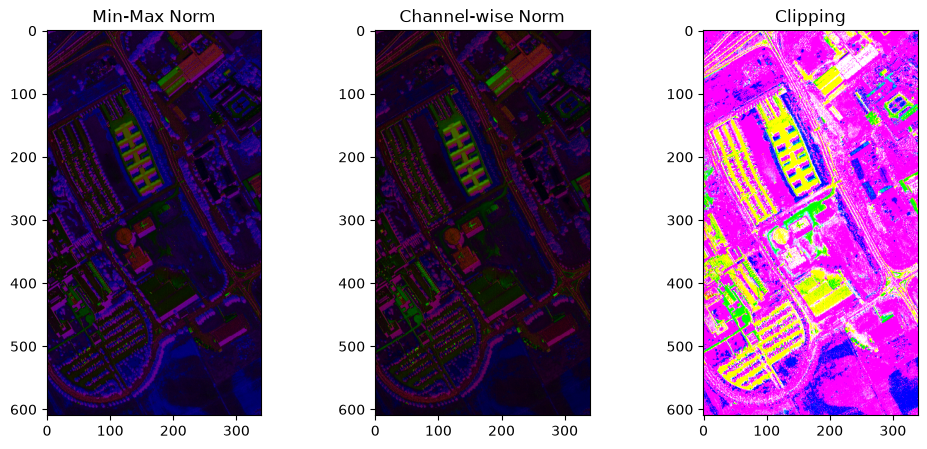

In [67]:
channels = [1, 2, 3]

predicted_image = predict_image()

normalized_images = normalize_images(
    predicted_image,
    channels
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(normalized_images[0])
plt.title("Min-Max Norm")

plt.subplot(1, 3, 2)
plt.imshow(normalized_images[1])
plt.title("Channel-wise Norm")

plt.subplot(1, 3, 3)
plt.imshow(normalized_images[2])
plt.title("Clipping")

plt.show()